## Customer Churn prediction using Machine Learning




Link to my Colab Research Report: https://colab.research.google.com/drive/1YFxehqTD-aLRr68d9I_b_pa9MaruUGyG?usp=sharing

## 1.Business understanding


Customer churn is a major issue for telecommunications companies, since retaining customers is seen as more cost-effective than acquiring new ones. In this report the business problem is to identify customers who are likely to leave the company (i.e churn).

The goal of this analysis is to develop a machine learning model that can predict whether a customer will churn based on historical data such as demographic information such as service usage, and customer interactions. By identifying customers at risk of churn, the company can take proactive measures, such as targeted retention strategies to reduce customer loss.

This problem can be framed as a supervised machine learning classification task, where the target variable is binary (churn vs non-churn). The model will learn patterns from past data and use them to predict future customer behaviour.


## 2. Data Understanding

The dataset used is the Acme Telephonica customer churn dataset. It contains information about customer demographics, billing and usage behaviour. The dataset includes both numerical and categorical variables such as age, income and number of calls and customer service interactions. The target variable is "churn", which indicates whether a customer has left the company.Initial exploration shows that the dataset is suitable for classification tasks and contains a mix of feature types that require pre-processing.


## 3. Data Preperation

**Example dataset**:	Mobile Phone Operator (Acme Telephonica) Customer Churn.
The dataset is loaded below and is described in the [materials](https://drive.google.com/file/d/1OIaC4wxf0y4w2A8kJSVmEd4HwnQTEPQJ/view) associated with the book *Fundamentals of Machine Learning for Predictive Data Analytics: Algorithms, Worked Examples, and Case Studies* by John D. Kelleher et al.

This step ensures that the dataset is clean and suitable for reliable model training and evaluation, which is essential for producing valid machine learning results.

In [ ]:
# Import libraries for data analysis and visualisation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the customer churn dataset
churn_data = pd.read_csv(
    "https://gitlab.com/valdanchev/data-storage-for-teaching-ml/-/raw/main/ACMETelephoneABT_cleaned.csv"
)

In [ ]:
# Display the first five rows
churn_data.head()

,customer,age,occupation,regionType,marriageStatus,children,income,numHandsets,handsetAge,smartPhone,...,avgInCalls,peakOffPeakRatio,peakOffPeakRatioChangePct,avgDroppedCalls,lifeTime,lastMonthCustomerCareCalls,numRetentionCalls,numRetentionOffersAccepted,newFrequentNumbers,churn
0,1000004,26,crafts,town,yes,1,6,1,1812,0,...,0.00,0.362398,-6.330770,0.00,60,0.00,0,0,0,0
1,1000012,36,NaN,NaN,yes,1,9,4,544,1,...,1.67,5.586826,7.499560,0.00,53,0.00,0,0,0,0
2,1000034,74,professional,town,yes,0,7,2,138,1,...,0.33,0.500000,-5.940493,4.33,58,0.00,0,0,3,0
3,1000063,30,NaN,suburban,no,0,6,3,122,1,...,4.67,8.629661,-0.066485,5.33,50,0.33,0,0,0,0
4,1000085,32,NaN,town,yes,0,7,8,10,1,...,23.00,14.042685,-7.208502,14.67,56,0.00,0,0,0,0


In [ ]:
# Check the number of rows and columns
churn_data.shape

(10000, 33)

The dataset contains customer-level information and includes both predictor variables and a target variable. Checking the dataset dimensions helps us understand how many observations and variables are available for the analysis.


In [ ]:
# Inspect variable names, data types, and non-missing values
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer                    10000 non-null  int64  
 1   age                         10000 non-null  int64  
 2   occupation                  2600 non-null   object 
 3   regionType                  5224 non-null   object 
 4   marriageStatus              10000 non-null  object 
 5   children                    10000 non-null  int64  
 6   income                      10000 non-null  int64  
 7   numHandsets                 10000 non-null  int64  
 8   handsetAge                  10000 non-null  int64  
 9   smartPhone                  10000 non-null  int64  
 10  currentHandsetPrice         10000 non-null  float64
 11  creditRating                10000 non-null  object 
 12  homeOwner                   10000 non-null  int64  
 13  creditCard                  1000

The dataset contains a mixture of numerical and categorical variables. This is important because different variable types may require different preparation steps later, such as standardisation for numerical features and dummy variables.


In [ ]:
# Summary statistics for numerical variables
churn_data.describe()

,customer,age,children,income,numHandsets,handsetAge,smartPhone,currentHandsetPrice,homeOwner,avgBill,...,avgInCalls,peakOffPeakRatio,peakOffPeakRatioChangePct,avgDroppedCalls,lifeTime,lastMonthCustomerCareCalls,numRetentionCalls,numRetentionOffersAccepted,newFrequentNumbers,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.049974e+06,30.318400,0.244100,4.293600,1.804500,390.171700,0.901500,35.730696,0.342300,58.927600,...,8.368029,2.217785,-0.046749,9.992283,18.836300,1.737414,0.044600,0.020700,0.195000,0.500000
std,2.879841e+04,22.158676,0.429574,3.139902,1.345088,257.076656,0.298004,57.072922,0.474503,43.889815,...,17.676847,3.882714,9.973846,14.859162,9.610928,5.754564,0.225867,0.155158,0.641261,0.500025
min,1.000001e+06,0.000000,0.000000,0.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-41.322736,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.025200e+06,0.000000,0.000000,0.000000,1.000000,210.000000,1.000000,0.000000,0.000000,33.327500,...,0.000000,0.779357,-6.791049,1.670000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.049833e+06,34.000000,0.000000,5.000000,1.000000,339.000000,1.000000,0.000000,0.000000,49.205000,...,2.000000,1.399874,0.011607,5.330000,17.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,1.074990e+06,48.000000,0.000000,7.000000,2.000000,525.000000,1.000000,59.990000,1.000000,71.762500,...,9.000000,2.494232,6.494723,12.670000,24.000000,1.330000,0.000000,0.000000,0.000000,1.000000
max,1.099988e+06,98.000000,1.000000,9.000000,21.000000,1812.000000,1.000000,499.990000,1.000000,584.230000,...,304.000000,160.000000,37.779743,304.670000,61.000000,365.670000,4.000000,4.000000,3.000000,1.000000


Descriptive statistics provide a first overview of the distribution of the numerical variables, including their mean, standard deviation, minimum, and maximum values. This helps identify possible skewness, unusual values and difference in scale across variables

In [ ]:
# Count customers who churned and did not churn
churn_data["churn"].value_counts()

,count
churn,
0,5000
1,5000


In [ ]:
# Proportion of customers who churned and did not churn
churn_data["churn"].value_counts(normalize=True)

,proportion
churn,
0,0.5
1,0.5


The target variable is "churn", which indicates whether a customer left the company. Examining its distribution is important because it shows whether the classes are balanced or imbalanced. A balanced target variable makes classification modelling easier to interpret.


In [ ]:
# Check missing values in each column
churn_data.isnull().sum()

,0
customer,0
age,0
occupation,7400
regionType,4776
marriageStatus,0
children,0
income,0
numHandsets,0
handsetAge,0
smartPhone,0


In [ ]:
# Percentage of missing values in each column
(churn_data.isnull().sum() / churn_data.shape[0]) * 100

,0
customer,0.00
age,0.00
occupation,74.00
regionType,47.76
marriageStatus,0.00
children,0.00
income,0.00
numHandsets,0.00
handsetAge,0.00
smartPhone,0.00


Checking missing values is an important part of data understanding because missingness can affect both visualisation and model building. In this dataset, some variables may contain missing observations and will need to be handled in the data preparation stage.


The dataset contains variables related to customer demographics, billing, usage, and retention activity. Examples include:

- `age`: customer age  
- `income`: customer income level  
- `lifeTime`: number of months the customer has been with the company  
- `avgBill`: average monthly bill  
- `avgMins`: average number of call minutes used  
- `numRetentionCalls`: number of calls made by the retention team  
- `numRetentionOffersAccepted`: number of retention offers accepted  
- `occupation` and `regionType`: customer background and location characteristics  
- `churn`: target variable indicating whether the customer churned

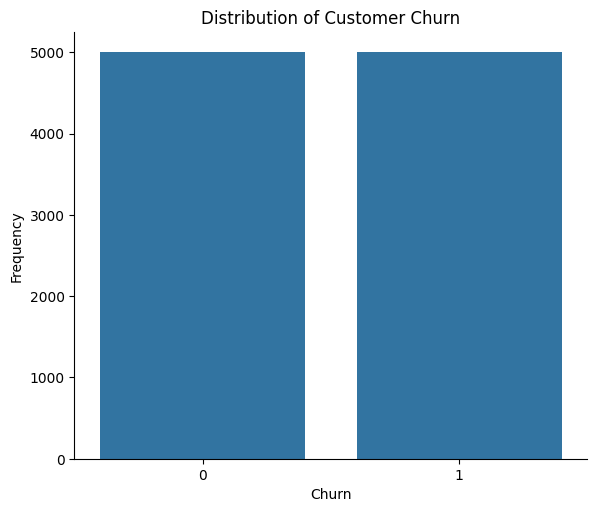

In [ ]:
# Plot the distribution of the churn variable
sns.catplot(x="churn", kind="count", data=churn_data, height=5, aspect=1.2)
plt.xlabel("Churn")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Churn")
plt.show()

The bar plot shows that the number of customers who churned and those who did not churn is approximately equal. This indicates that the dataset is balanced in terms of the target variable. A balanced dataset is beneficial for classification tasks because it allows the model to learn patterns for both classes equally, reducing the risk of bias toward one class.

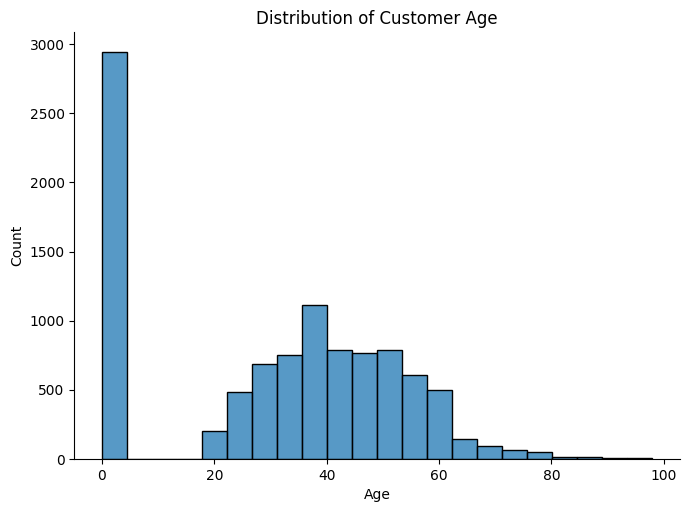

In [ ]:
# Histogram of customer age
sns.displot(churn_data["age"].dropna(), height=5, aspect=1.4)
plt.xlabel("Age")
plt.title("Distribution of Customer Age")
plt.show()

The histogram shows the distribution of customer age. Most customers are between approximately 25 and 60 years old, with a peak around the middle age range, indicating that the majority of customers fall within this group.

However, there is a noticeable spike at age = 0, which is not realistic. This likely represents missing or incorrectly recorded data. This issue will need to be addressed during the data preparation stage to ensure accurate model performance.



Additionally, the distribution appears to be slightly right skewed, with fewer customers in older age ranges above 60. This suggests that older customers are less represented in the dataset. Understanding the distribution of age is important because age may influence customer behaviour, including the likelihood of churn.

For example, different age groups may have different usage patterns or responsiveness to retention strategies.

Overall, this analysis highlights both the general pattern of customer ages and a potential data quality issue that will need to be addressed in the next stage of the analysis.



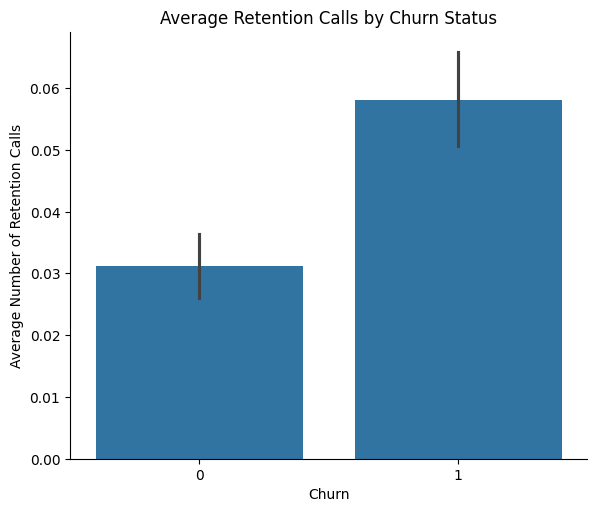

In [ ]:
# Compare retention calls by churn status
sns.catplot(data=churn_data, x="churn", y="numRetentionCalls", kind="bar", height=5, aspect=1.2)
plt.xlabel("Churn")
plt.ylabel("Average Number of Retention Calls")
plt.title("Average Retention Calls by Churn Status")
plt.show()

This plot compares the average number of retention calls for customers who churned and those who did not churn. Customers who have churned have a higher average number of retention calls compared to those who did not churn.

This suggests that customers who are at risk of leaving are more likely to be contacted by the company's retention team. However, the higher number of retention calls amongst churned customers may indicate that these efforts are not always effective in preventing churn.

Therefore the number of retention calls may be an important predictor of churn and should be included in the machine learning model.

### Summary of Data Understanding
The dataset contains customer demographic, usage, and retention-related variables that can be used to predict churn. Initial exploration showed that the target variable is balanced, which is beneficial for classification tasks.

The analysis also identified potential data quality issues, such as unrealistic values in the age variable which will need to be addressed during data preparation.

Visualisations of key variables provided insight into customer characteristics such as age and retention calls and highlighted features that may be useful for predicting churn. However, further analysis through machine learning models is required to confirm their importance. Overall, this stage provided a clear understanding of the dataset and informed steps in the analysis.



### 3. Data Preperation

Data pre-processing and model training steps follow standard machine learning practices using tools such as Scikit- learn (Géron, 2019)

In [ ]:
# Import numpy for missing value handling
import numpy as np

In [ ]:
# Replace unrealistic age values (0) with NaN
churn_data["age"] = churn_data["age"].replace(0, np.nan)

In [ ]:
# Check missing values after replacing age = 0
churn_data.isnull().sum()

,0
customer,0
age,2942
occupation,7400
regionType,4776
marriageStatus,0
children,0
income,0
numHandsets,0
handsetAge,0
smartPhone,0


In [ ]:
# Remove rows with missing values
churn_data = churn_data.dropna()

In [ ]:
# Check the size of the cleaned dataset
churn_data.shape

(1591, 33)

In [ ]:
# Separate input features and target variable
X = churn_data.drop("churn", axis=1)
y = churn_data["churn"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Convert categorical variables in the training data into dummy variables
X_train = pd.get_dummies(X_train, drop_first=True)

In [ ]:
# Convert categorical variables in the test data into dummy variables
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
# Make sure the training and test sets have the same columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Create a scaler object
scaler = StandardScaler()

In [ ]:
# Standardise the training predictors
X_train = scaler.fit_transform(X_train)

In [ ]:
# Standardise the test predictors using the same scaler
X_test = scaler.transform(X_test)

In [ ]:
# Check the shape of the final training and test data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1272, 51)
X_test shape: (319, 51)
y_train shape: (1272,)
y_test shape: (319,)


During the data preparation, unrealistic values in the 'age' variable are identified and treated as missing data. Rows containing missing values were then removed to create a complete dataset for modelling.

Next the predictor variables and target variables were separated, and the data was split into training and test sets. This is important because the model should be evaluated on unseen data rather than on the same data used for training.

Categorical variables were converted into dummy variables, and the training and test datasets were aligned to ensure they contained the same features. Finally, numerical features were standardized using 'StandardScaler'. Standardisation was applied after the train-test split to avoid data leakage and improve reliability of model evaluation.



## 4. Modelling

Logistic Regression is a commonly used classification algorithm for predicting binary outcomes. (Provost and Fawcett, 2013)


In [ ]:
# Import logistic regression model
from sklearn.linear_model import LogisticRegression

In [ ]:
# Create and train the logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation on logistic regression
cv_scores = cross_val_score(log_model, X_train, y_train, cv=5)

# Show results
print("Cross-validation scores:", cv_scores)
print("Average CV score:", cv_scores.mean())

Cross-validation scores: [0.57647059 0.52941176 0.5511811  0.57480315 0.51968504]
Average CV score: 0.5503103288559518


Cross validation was used to evaluate the performance of the logistic regression model on different subsets of the training data. This helps to ensure that the model is not overly dependent on a single train-set and provides a more reliable estimate of model performance.

The average cross-validation score indicates that the model performs consistently across different subsets for the data.

In [ ]:
# Make predictions using the logistic regression model
y_pred_log = log_model.predict(X_test)

In [ ]:
# Import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create and train the decision tree model
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
# Make predictions using the decision tree model
y_pred_tree = tree_model.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Create KNN model with k = 5
knn_model = KNeighborsClassifier(n_neighbors=5)

The depth of the Decision Tree was limited tp prevent overfitting and improve generalisation

In [ ]:
# Train KNN model
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Predictions using KNN
y_pred_knn = knn_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

accuracy_scores

[0.5329153605015674,
 0.5611285266457681,
 0.4827586206896552,
 0.5297805642633229,
 0.5454545454545454,
 0.5329153605015674,
 0.5015673981191222,
 0.4890282131661442,
 0.4952978056426332,
 0.5109717868338558,
 0.46394984326018807,
 0.49843260188087773,
 0.5235109717868338,
 0.5203761755485894,
 0.5391849529780565,
 0.5391849529780565,
 0.5579937304075235,
 0.54858934169279,
 0.5235109717868338,
 0.5391849529780565]

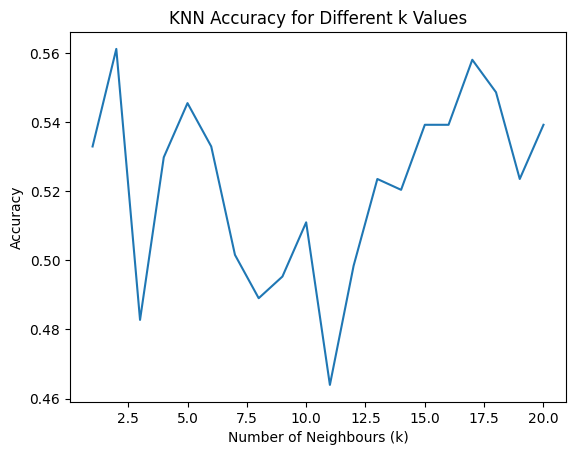

In [ ]:
import matplotlib.pyplot as plt

plt.plot(k_values, accuracy_scores)
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different k Values")
plt.show()

In [ ]:
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
best_k

2

In [ ]:
# Train final KNN with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

KNN is sensitive to the scale of data, therefore the feature standardisation was neccessary before applying the algorithm.

Two classification models were trained : Logistic regression and Decision tree. Logistic regression was used as a simple baseline model, while Decision Tree was included because it can capture more complex relationships between customer features and churn.

Both models were trained using the training dataset and later evaluated on the test dataset to assess how well they generalise to unseen data.

In addition to Logistic Regression, and Decision Tree, a K-nearest neighbors (KNN) model was implemented. KNN is a non-parametric algorithm that classifies observations based on the majority class of their nearest neighbors in the feature space. To improve model performance, the hyperparameter k (number of neighbours) was tuned by testing values from 1 to 20. The model performance was evaluated using accuracy, and the value of the k that produced the highest accuracy was selected.

The results show that the optimal value of k was 2, which produced the highest accuracy. However, the overall accuracy of the KNN model was relatively low with the values around 50-56%. This suggests that the model may not be capturing strong patterns in the data. Additionally, the optimal k value being very small may indicate a risk of over fitting as the model is relying on very localised patterns in the dataset. This highlights a limitation of the KNN approach for this particular problem.



## 5. Evaluation

Model evaluation is essential to ensure that predictive models generalise well to unseen data and do not suffer from overfitting (Kelleher et al., 2015)

In [ ]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Evaluate Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.5454545454545454
Confusion Matrix:
[[95 81]
 [64 79]]
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.54      0.57       176
           1       0.49      0.55      0.52       143

    accuracy                           0.55       319
   macro avg       0.55      0.55      0.54       319
weighted avg       0.55      0.55      0.55       319



The Logistic Regression model achieved an accuracy of approximately 55% on the test dataset, indicating moderate predictive performance. The confusion matrix shows that the model correctly identifies both churn and non-churn cases, although a significant number of misclassifications are present.

The classification report indicates that the model has a recall of 0.55 for churn prediction, meaning that it correctly identifies around 55% of customers who actually churn. This is important from a business perspective, as identifying customers at risk of leaving is a key objective.

However, the relatively low precision and overall accuracy suggest that the model struggles to clearly distinguish between churn and non-churn customers. This may indicate that the relationships between features and churn are not purely linear, limiting the effectiveness of Logistic Regression for this task



In [ ]:
# Evaluate Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.5235109717868338
Confusion Matrix:
[[104  72]
 [ 80  63]]
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.59      0.58       176
           1       0.47      0.44      0.45       143

    accuracy                           0.52       319
   macro avg       0.52      0.52      0.52       319
weighted avg       0.52      0.52      0.52       319



The Decision Tree model achieved an accuracy of approximately 52% on the test dataset, which is slightly lower than the Logistic Regression model. This suggests that the Decision Tree does not perform as well overall for this prediction task. The confusion matrix shows that the model is better at predicting non-churn customers than churn customers. In particular, the recall for churn is relatively low (0.44), meaning that the model fails to identify a significant proportion of customers who actually churn.

Although Decision Trees are capable of capturing non-linear relationships, the restricted tree depth (max_depth=5) may limit its ability to fully learn complex patterns in the data. However, this restriction helps reduce the risk of overfitting.

Overall, the Decision Tree Model demonstrates weaker performance compared to logistic regression, particularly in identifying customers at risk of churn.

In [ ]:
# Evaluate KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.5611285266457681
Confusion Matrix:
[[142  34]
 [106  37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.81      0.67       176
           1       0.52      0.26      0.35       143

    accuracy                           0.56       319
   macro avg       0.55      0.53      0.51       319
weighted avg       0.55      0.56      0.52       319



The performance of the three models was compared using accuracy, confusion matrices, and classification reports. The K-Nearest (KNN) model achieved the highest overall accuracy of approximately 56%, slightly outperforming Logistic Regression (55%) and Decision Tree (52%).

However, a deeper analysis of the classification results reveals important limitations. Although KNN achieved the highest accuracy, its recall for churn prediction was relatively low (0.26), meaning that it failed to correctly identify a large proportion of customers who actually churned. This is a significant drawback, as identifying churners is a key objective for the business.

Logistic Regression demonstrated more balanced performance, with higher recall for churn (0.55), indicating that it was more effective at identifying customers at risk of leaving. Although its overall accuracy was slightly lower than KNN, its ability to detect churners makes it a more practical model in this context.

The Decision Tree model showed the weakest performance overall with the lowest accuracy and recall for churn. The use of restricted tree depth helped reduce overfitting but may have limited the model's ability to capture complex patterns in the data.

Overall, the results suggest that while KNN achieved the highest accuracy, Logistic Regression may be more suitable for this problem due to its better performance in identifying churners. This highlights the importance of considering multiple evaluation metrics rather than relying solely on accuracy when assessing model performance.



In [ ]:
# Compare model accuracy
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN"],
    "Accuracy": [accuracy_log, accuracy_tree, accuracy_knn]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.545455
1,Decision Tree,0.523511
2,KNN,0.561129


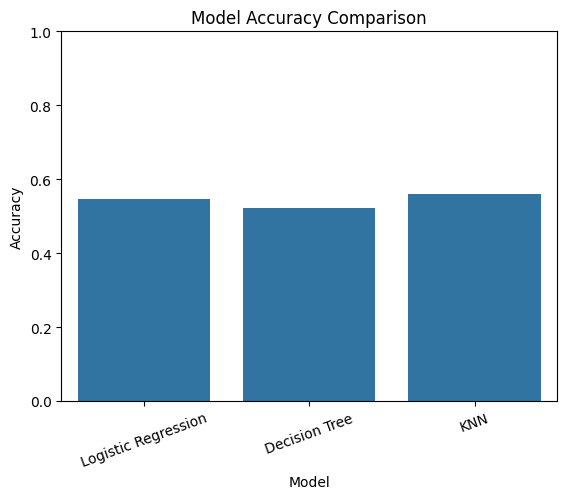

In [ ]:
# Visualise model accuracy comparison
sns.barplot(data=model_results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

A comparison of model accuracy shows that the K-Nearest Neighbours (KNN) model achieved the highest accuracy followed closely by Logistic Regression and Decision Tree performed the weakest.

The difference in accuracy between the models are relatively small, suggesting that none of the models provides a significantly better fit for the data. This indicates that predicting customer churn is a challenging task with the available features.

Furthermore, although KNN achieved the highest accuracy, earlier analysis showed that its recall for churn prediction was relatively low. This highlights the importance of considering multiple evaluation metrics, as accuracy alone may not fully reflect model performance in a business context.

These results also highlight the potential impact of the bias-variance trade-off where simpler models such as Logistic Regression may underfit the data, while more flexible models such as KNN may overfit to local patterns.

From a business perspective, recall for churn prediction is particularly important, as failing to identify customers who are likley to leave may result in lost revenue.  Therefore, models that achieve higher recall for churn may be more valuable in practice, even if their overall accuracy is slightly lower.

## 6. Conclusions
The aim of this project was to develop machine learning models to predict customer churn using the Acme Telephonica dataset. This represents an important business problem, as accurately identifying customers at risk of leaving can help organisations implement targeted retention strategies and reduce revenue loss.

Three classification models were applied: Logistic Regression, Decision Tree, and K-Nearest Neighbours (KNN). These results showed that all models achieved moderate levels of accuracy, with KNN performing slightly better in terms of overall accuracy. However, further analysis revealed that KNN had a relatively low recall for churn prediction, meaning it failed to identify a significant proportion of customers who actually churned.

Logistic Regression provided more balanced performance and was better at identifying churners, which is particularly important from a business perspective. The Decision Tree Model showed the weakest performance, possibly due to restricted tree depth, which limited its ability to capture complex patterns in the data.

Overall, the results suggest that predicting customer churn is a challenging task using the available features. The relatively modest performance of all models indicates that additional data or perhaps more advanced modelling techniques may be required to improve predictive accuracy.

In conclusion, while machine learning can provide useful insights into customer churn, the effectiveness of prediction models depends heavily on the quality and relevance of the available data. This project highlights the importance of both model selection and careful evaluation when applying machine learning to real-world business problems.



### 7. References

Provost & Fawcett. 2013. [Data Science for Business](https://go.oreilly.com/queen-mary-university-of-london/library/view/data-science-for/9781449374273/). O’Reilly Media.

Kelleher et al. 2015. [Fundamentals of Machine Learning for Predictive Data Analytics](https://machinelearningbook.com). MIT Press.

Géron, A. (2019) *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O’Reilly.